In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedStratifiedKFold, RandomizedSearchCV, cross_validate
from xgboost import XGBClassifier

gp = pd.read_csv(os.path.join("data", "gp_objects_rates.csv"))
bulla = pd.read_csv(os.path.join("data", "bulla_2019_rates.csv"))

gp = gp.drop(columns=[c for c in gp.columns if "peak_time" in str(c)], errors="ignore")
bulla = bulla.drop(columns=[c for c in bulla.columns if "peak_time" in str(c)], errors="ignore")

common_numeric = sorted(
    set(gp.select_dtypes(include=np.number).columns)
    & set(bulla.select_dtypes(include=np.number).columns)
)
if not common_numeric:
    raise ValueError("No shared numeric columns found.")

X_all = pd.concat([gp[common_numeric], bulla[common_numeric]], ignore_index=True)
all_types = pd.concat(
    [gp["type"].fillna("Unknown").astype(str), pd.Series(["bulla_kilonova_model"] * len(bulla))],
    ignore_index=True
)

MIN_SUPPORT = 1
type_counts = all_types.value_counts()
classes = [c for c, n in type_counts.items() if n >= MIN_SUPPORT]

print(f"Total classes: {all_types.nunique()} | analyzed (support >= {MIN_SUPPORT}): {len(classes)}")

Total classes: 16 | analyzed (support >= 1): 16


In [2]:
def make_cv_binary(y, max_splits=5, n_repeats=2, random_state=42):
    pos = int(np.sum(y == 1))
    neg = int(np.sum(y == 0))
    n_splits = max(2, min(max_splits, pos, neg))
    return RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)

def make_xgb(scale_pos_weight=1.0, random_state=42):
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        n_jobs=-1,
        random_state=random_state,
        learning_rate=0.05,
        n_estimators=350,
        max_depth=4,
        min_child_weight=1,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        gamma=0.0,
        scale_pos_weight=scale_pos_weight,
    )

def tune_xgb_binary_ovr(X_df, y_bin, random_state=42, n_iter=16):
    pos = int(np.sum(y_bin == 1))
    neg = int(np.sum(y_bin == 0))
    spw = neg / max(pos, 1)

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("xgb", make_xgb(scale_pos_weight=spw, random_state=random_state))
    ])

    param_dist = {
        "xgb__n_estimators": [200, 350, 500],
        "xgb__max_depth": [3, 4, 5, 6],
        "xgb__learning_rate": [0.03, 0.05, 0.08],
        "xgb__min_child_weight": [1, 3, 5],
        "xgb__subsample": [0.7, 0.85, 1.0],
        "xgb__colsample_bytree": [0.7, 0.85, 1.0],
        "xgb__gamma": [0.0, 0.25, 1.0],
        "xgb__reg_lambda": [1.0, 3.0, 10.0],
    }

    cv = make_cv_binary(y_bin, max_splits=5, n_repeats=2, random_state=random_state)

    rs = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        random_state=random_state,
        refit=True,
    )
    rs.fit(X_df, y_bin)
    return rs.best_params_, float(rs.best_score_)

In [3]:
TOP_N_PER_CLASS = 5
TUNE_PER_CLASS = True  # set False for faster run

ovr_summary_rows = []
ovr_feature_rows = []

for i, cls in enumerate(classes, start=1):
    y_cls = (all_types.values == cls).astype(int)
    pos = int(y_cls.sum())
    neg = int((1 - y_cls).sum())

    if min(pos, neg) < 2:
        continue

    print(f"[{i}/{len(classes)}] Class: {cls} | pos={pos} neg={neg}")

    if TUNE_PER_CLASS:
        best_params, best_auc = tune_xgb_binary_ovr(X_all, y_cls, random_state=42 + i, n_iter=16)
        tuned = {k.replace("xgb__", ""): v for k, v in best_params.items()}
    else:
        best_params, best_auc, tuned = {}, np.nan, {}

    spw = neg / max(pos, 1)
    model = make_xgb(scale_pos_weight=spw, random_state=123 + i)
    if tuned:
        model.set_params(**tuned)

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("xgb", model)
    ])

    cv = make_cv_binary(y_cls, max_splits=5, n_repeats=3, random_state=100 + i)

    full_scores = cross_validate(
        pipe, X_all, y_cls, cv=cv,
        scoring={"bal_acc": "balanced_accuracy", "roc_auc": "roc_auc"},
        n_jobs=-1, error_score=np.nan
    )

    ovr_summary_rows.append({
        "object_type": cls,
        "support": pos,
        "tuned_cv_roc_auc": best_auc,
        "full_bal_acc_mean": np.nanmean(full_scores["test_bal_acc"]),
        "full_bal_acc_std": np.nanstd(full_scores["test_bal_acc"]),
        "full_roc_auc_mean": np.nanmean(full_scores["test_roc_auc"]),
        "full_roc_auc_std": np.nanstd(full_scores["test_roc_auc"]),
        "best_params": best_params
    })

    for col in common_numeric:
        s = cross_validate(
            pipe, X_all[[col]], y_cls, cv=cv,
            scoring={"bal_acc": "balanced_accuracy", "roc_auc": "roc_auc"},
            n_jobs=-1, error_score=np.nan
        )
        ovr_feature_rows.append({
            "object_type": cls,
            "support": pos,
            "feature": col,
            "balanced_acc_mean": np.nanmean(s["test_bal_acc"]),
            "balanced_acc_std": np.nanstd(s["test_bal_acc"]),
            "roc_auc_mean": np.nanmean(s["test_roc_auc"]),
            "roc_auc_std": np.nanstd(s["test_roc_auc"]),
        })

ovr_summary = pd.DataFrame(ovr_summary_rows).sort_values("full_roc_auc_mean", ascending=False).reset_index(drop=True)
ovr_feature_results = pd.DataFrame(ovr_feature_rows).sort_values(
    ["object_type", "balanced_acc_mean"], ascending=[True, False]
).reset_index(drop=True)

top_discriminators_by_type = (
    ovr_feature_results.groupby("object_type", group_keys=False)
    .head(TOP_N_PER_CLASS)
    .reset_index(drop=True)
)

[1/16] Class: bulla_kilonova_model | pos=2200 neg=72
[2/16] Class: IIb | pos=21 neg=2251
[3/16] Class: Cataclysmic | pos=11 neg=2261
[4/16] Class: II | pos=9 neg=2263
[5/16] Class: Afterglow | pos=7 neg=2265
[6/16] Class: Novae | pos=7 neg=2265
[7/16] Class: Ia | pos=4 neg=2268
[8/16] Class: Ibn | pos=3 neg=2269
[9/16] Class: Ib | pos=3 neg=2269


In [4]:
print("=== OVR class-level summary ===")
display(ovr_summary[["object_type", "support", "full_bal_acc_mean", "full_roc_auc_mean", "tuned_cv_roc_auc"]])

print(f"\n=== Top {TOP_N_PER_CLASS} single-feature discriminators per class ===")
display(top_discriminators_by_type)

best_feature_per_type = (
    ovr_feature_results.sort_values(["object_type", "balanced_acc_mean"], ascending=[True, False])
    .groupby("object_type", as_index=False)
    .first()[["object_type", "support", "feature", "balanced_acc_mean", "roc_auc_mean"]]
    .sort_values("balanced_acc_mean", ascending=False)
    .reset_index(drop=True)
)
display(best_feature_per_type)

=== OVR class-level summary ===


,object_type,support,full_bal_acc_mean,full_roc_auc_mean,tuned_cv_roc_auc
0,Afterglow,7,0.932377,0.999890,0.999890
1,Ibn,3,0.943563,0.999265,0.999339
2,Novae,7,0.849043,0.999043,0.998455
3,Cataclysmic,11,0.998673,0.998746,0.999226
4,Ia,4,0.748310,0.996620,0.996693
5,IIb,21,0.913521,0.992559,0.994992
6,bulla_kilonova_model,2200,0.958608,0.990082,0.992769
7,II,9,0.794330,0.988037,0.989063
8,Ib,3,0.665197,0.829993,0.910570



=== Top 5 single-feature discriminators per class ===


,object_type,support,feature,balanced_acc_mean,balanced_acc_std,roc_auc_mean,roc_auc_std
0,Afterglow,7,ztfr_peak_mag,0.999043,0.001388,0.999043,0.001388
1,Afterglow,7,ztfi_peak_mag,0.989257,0.002434,0.990692,0.003953
2,Afterglow,7,ztfg_peak_mag,0.931199,0.142391,0.932082,0.142799
3,Afterglow,7,ztfr_fade_rate,0.912693,0.149580,0.910155,0.177046
4,Afterglow,7,ztfi_peak_gi_color,0.870971,0.178059,0.930427,0.130822
5,Cataclysmic,11,ztfg_peak_mag,0.998157,0.001438,0.998488,0.001631
6,Cataclysmic,11,ztfr_peak_mag,0.998157,0.001438,0.998488,0.001631
7,Cataclysmic,11,ztfi_peak_mag,0.989165,0.003309,0.992481,0.004695
8,Cataclysmic,11,ztfg_peak_gi_color,0.940888,0.089587,0.918082,0.134376
9,Cataclysmic,11,ztfi_peak_gi_color,0.914362,0.104878,0.915871,0.135482


,object_type,support,feature,balanced_acc_mean,roc_auc_mean
0,Afterglow,7,ztfr_peak_mag,0.999043,0.999043
1,Cataclysmic,11,ztfg_peak_mag,0.998157,0.998488
2,Novae,7,ztfg_peak_mag,0.996909,0.997351
3,Ibn,3,ztfr_peak_mag,0.996548,0.997943
4,Ib,3,ztfi_fade_rate,0.990377,0.990377
5,Ia,4,ztfi_peak_mag,0.988830,0.992504
6,bulla_kilonova_model,2200,ztfg_peak_mag,0.946652,0.954484
7,IIb,21,ztfg_peak_mag,0.919413,0.953475
8,II,9,ztfg_peak_mag,0.906136,0.939471


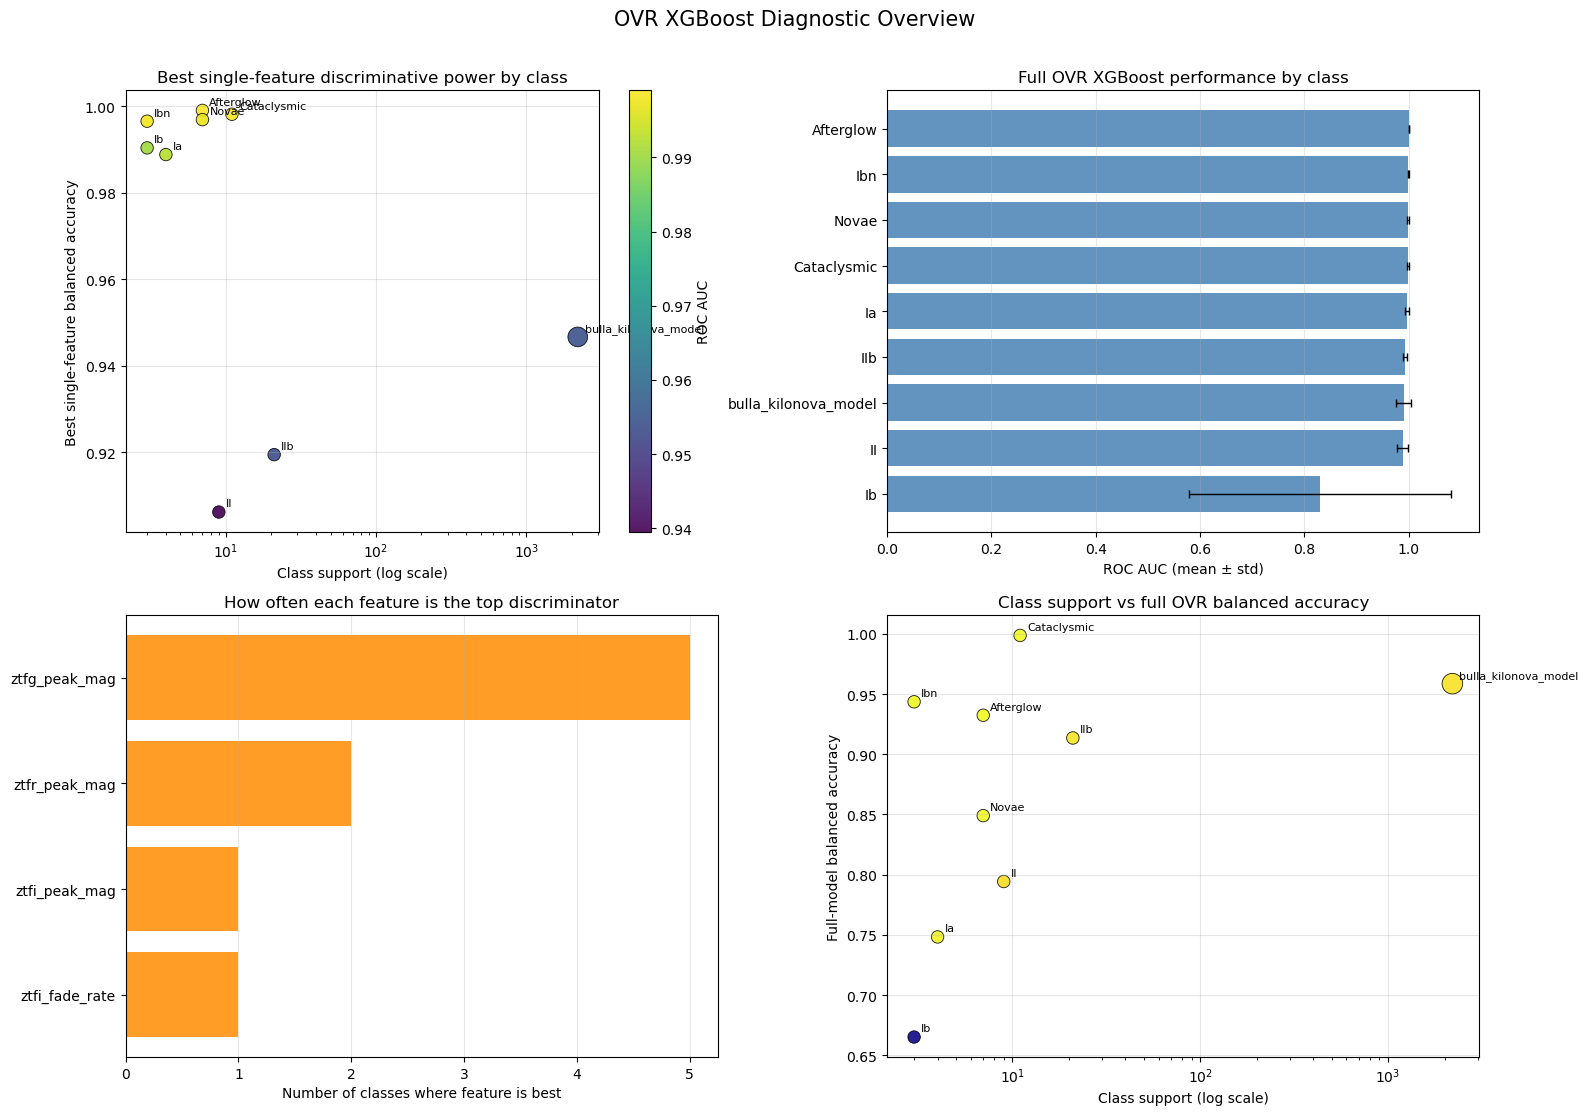

In [5]:
# Prepare plotting views
bf = best_feature_per_type.sort_values("support", ascending=True).copy()
ovr = ovr_summary.sort_values("full_roc_auc_mean", ascending=True).copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# --- (1) Best single-feature quality by class (annotated scatter)
ax = axes[0, 0]
sizes = 80 + 120 * (bf["support"] / bf["support"].max())
sc = ax.scatter(
    bf["support"],
    bf["balanced_acc_mean"],
    c=bf["roc_auc_mean"],
    s=sizes,
    cmap="viridis",
    edgecolor="black",
    linewidth=0.6,
    alpha=0.9
)
ax.set_xscale("log")
ax.set_xlabel("Class support (log scale)")
ax.set_ylabel("Best single-feature balanced accuracy")
ax.set_title("Best single-feature discriminative power by class")

for _, r in bf.iterrows():
    ax.annotate(
        r["object_type"],
        (r["support"], r["balanced_acc_mean"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8
    )

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("ROC AUC")
ax.grid(alpha=0.3)

# --- (2) Full OVR model ROC AUC by class
ax = axes[0, 1]
ax.barh(ovr["object_type"], ovr["full_roc_auc_mean"], color="steelblue", alpha=0.85)
ax.errorbar(
    ovr["full_roc_auc_mean"],
    ovr["object_type"],
    xerr=ovr["full_roc_auc_std"],
    fmt="none",
    ecolor="black",
    elinewidth=1,
    capsize=3
)
ax.set_xlabel("ROC AUC (mean ± std)")
ax.set_title("Full OVR XGBoost performance by class")
ax.grid(axis="x", alpha=0.3)

# --- (3) Best single feature usage frequency across classes
ax = axes[1, 0]
feature_counts = bf["feature"].value_counts().sort_values(ascending=True)
ax.barh(feature_counts.index, feature_counts.values, color="darkorange", alpha=0.85)
ax.set_xlabel("Number of classes where feature is best")
ax.set_title("How often each feature is the top discriminator")
ax.grid(axis="x", alpha=0.3)

# --- (4) Support vs full-model balanced accuracy (with labels)
ax = axes[1, 1]
sizes2 = 80 + 140 * (ovr["support"] / ovr["support"].max())
ax.scatter(
    ovr["support"],
    ovr["full_bal_acc_mean"],
    s=sizes2,
    c=ovr["full_roc_auc_mean"],
    cmap="plasma",
    edgecolor="black",
    linewidth=0.6,
    alpha=0.9
)
for _, r in ovr.iterrows():
    ax.annotate(
        r["object_type"],
        (r["support"], r["full_bal_acc_mean"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8
    )
ax.set_xscale("log")
ax.set_xlabel("Class support (log scale)")
ax.set_ylabel("Full-model balanced accuracy")
ax.set_title("Class support vs full OVR balanced accuracy")
ax.grid(alpha=0.3)

plt.suptitle("OVR XGBoost Diagnostic Overview", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

Second and nth order feature analysis

In [6]:
import itertools
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Create second and third order derived features
def create_derived_features(X_df, common_numeric, max_order=3, include_interactions=True):
    """
    Generate polynomial and custom derived features.
    Returns a DataFrame with original + derived features.
    """
    X_work = X_df[common_numeric].copy()
    X_work = X_work.fillna(X_work.median())
    
    derived = {}
    
    # --- Polynomial features (order 2 & 3) ---
    if include_interactions:
        poly2 = PolynomialFeatures(degree=2, include_bias=False)
        poly2_features = poly2.fit_transform(X_work)
        poly2_names = poly2.get_feature_names_out(common_numeric)
        for name, vals in zip(poly2_names, poly2_features.T):
            if name not in common_numeric:  # Skip originals
                derived[f"poly2_{name}"] = vals
        
        poly3 = PolynomialFeatures(degree=3, include_bias=False)
        poly3_features = poly3.fit_transform(X_work)
        poly3_names = poly3.get_feature_names_out(common_numeric)
        for name, vals in zip(poly3_names, poly3_features.T):
            if name not in common_numeric and f"poly2_{name}" not in derived:
                derived[f"poly3_{name}"] = vals
    
    # --- Custom "funky" derived features ---
    # Peak magnitude ratios (color-like but normalized differently)
    for c1, c2 in [('ztfg_peak_mag', 'ztfr_peak_mag'), 
                     ('ztfr_peak_mag', 'ztfi_peak_mag'),
                     ('ztfg_peak_mag', 'ztfi_peak_mag')]:
        if c1 in X_work.columns and c2 in X_work.columns:
            ratio = X_work[c1] / (X_work[c2] + 1e-5)
            derived[f"mag_ratio_{c1.split('_')[0]}_{c2.split('_')[0]}"] = ratio
    
    # Rise vs fade asymmetry
    for band in ['ztfg', 'ztfr', 'ztfi']:
        rise_cols = [c for c in X_work.columns if f"{band}_rise_hwhm" in c]
        fade_cols = [c for c in X_work.columns if f"{band}_fade_hwhm" in c]
        if rise_cols and fade_cols:
            asymmetry = X_work[f"{band}_rise_hwhm"] / (X_work[f"{band}_fade_hwhm"] + 1e-5)
            derived[f"asymmetry_{band}"] = asymmetry
    
    # Rise/fade rates vs width (timescale efficiency)
    for band in ['ztfg', 'ztfr', 'ztfi']:
        if f"{band}_rise_rate" in X_work.columns and f"{band}_fwhm" in X_work.columns:
            efficiency = X_work[f"{band}_rise_rate"] * X_work[f"{band}_fwhm"]
            derived[f"rise_efficiency_{band}"] = efficiency
        if f"{band}_fade_rate" in X_work.columns and f"{band}_fwhm" in X_work.columns:
            efficiency = X_work[f"{band}_fade_rate"] * X_work[f"{band}_fwhm"]
            derived[f"fade_efficiency_{band}"] = efficiency
    
    # Color gradients (change in color across bands)
    if 'ztfg_peak_gr_color' in X_work.columns and 'ztfr_peak_gr_color' in X_work.columns:
        derived["color_grad_gr"] = X_work['ztfg_peak_gr_color'] - X_work['ztfr_peak_gr_color']
    if 'ztfg_peak_gi_color' in X_work.columns and 'ztfi_peak_gi_color' in X_work.columns:
        derived["color_grad_gi"] = X_work['ztfg_peak_gi_color'] - X_work['ztfi_peak_gi_color']
    
    # Multi-band peak magnitude variance
    mag_cols = [c for c in X_work.columns if 'peak_mag' in c]
    if len(mag_cols) >= 2:
        derived["peak_mag_variance"] = X_work[mag_cols].var(axis=1)
        derived["peak_mag_range"] = X_work[mag_cols].max(axis=1) - X_work[mag_cols].min(axis=1)
    
    # Rise rate vs fade rate ratio (evolution timescale)
    for band in ['ztfg', 'ztfr', 'ztfi']:
        if f"{band}_rise_rate" in X_work.columns and f"{band}_fade_rate" in X_work.columns:
            derived[f"rise_fade_ratio_{band}"] = X_work[f"{band}_rise_rate"] / (X_work[f"{band}_fade_rate"] + 1e-5)
    
    # Logarithmic transforms for highly skewed features
    for col in ['ztfg_fwhm', 'ztfr_fwhm', 'ztfi_fwhm', 'ztfg_rise_hwhm', 'ztfr_rise_hwhm', 'ztfi_rise_hwhm']:
        if col in X_work.columns:
            derived[f"log_{col}"] = np.log1p(np.abs(X_work[col]))
    
    # Reciprocal features (for rate-based metrics)
    for col in [c for c in X_work.columns if 'rate' in c]:
        derived[f"inv_{col}"] = 1.0 / (np.abs(X_work[col]) + 1e-5)
    
    result_df = pd.concat([X_work, pd.DataFrame(derived)], axis=1)
    return result_df, list(derived.keys())

# Generate derived features
X_derived, derived_feature_names = create_derived_features(X_all, common_numeric)
print(f"Created {len(derived_feature_names)} derived features")
print(f"Total features: {X_derived.shape[1]}")
print(f"Sample derived features: {derived_feature_names[:10]}")

Created 2931 derived features
Total features: 2955
Sample derived features: ['poly2_ztfg_fade_hwhm^2', 'poly2_ztfg_fade_hwhm ztfg_fade_rate', 'poly2_ztfg_fade_hwhm ztfg_fwhm', 'poly2_ztfg_fade_hwhm ztfg_peak_gi_color', 'poly2_ztfg_fade_hwhm ztfg_peak_gr_color', 'poly2_ztfg_fade_hwhm ztfg_peak_mag', 'poly2_ztfg_fade_hwhm ztfg_rise_hwhm', 'poly2_ztfg_fade_hwhm ztfg_rise_rate', 'poly2_ztfg_fade_hwhm ztfi_fade_hwhm', 'poly2_ztfg_fade_hwhm ztfi_fade_rate']


In [7]:
import pickle
out_path = "artifacts/ovr_cache.pkl"
try:
    with open(out_path, "rb") as f:
        cached = pickle.load(f)
        globals().update(cached)
except FileNotFoundError:
    print(f"Cache file not found: {out_path}")

In [8]:
from joblib import Parallel, delayed

# Analyze derived features with OVR classification
derived_summary_rows = []
derived_feature_results = []

for i, cls in enumerate(classes, start=1):
    y_cls = (all_types.values == cls).astype(int)
    pos = int(y_cls.sum())
    neg = int((1 - y_cls).sum())

    if min(pos, neg) < 2:
        continue

    print(f"[{i}/{len(classes)}] Class: {cls} | pos={pos} neg={neg} | Testing {len(derived_feature_names)} derived features")

    spw = neg / max(pos, 1)
    model = make_xgb(scale_pos_weight=spw, random_state=123 + i)

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("xgb", model)
    ])

    cv = make_cv_binary(y_cls, max_splits=5, n_repeats=3, random_state=100 + i)

    # Test full derived feature set
    full_scores_derived = cross_validate(
        pipe, X_derived, y_cls, cv=cv,
        scoring={"bal_acc": "balanced_accuracy", "roc_auc": "roc_auc"},
        n_jobs=-1, error_score=np.nan
    )

    derived_summary_rows.append({
        "object_type": cls,
        "support": pos,
        "derived_bal_acc_mean": np.nanmean(full_scores_derived["test_bal_acc"]),
        "derived_bal_acc_std": np.nanstd(full_scores_derived["test_bal_acc"]),
        "derived_roc_auc_mean": np.nanmean(full_scores_derived["test_roc_auc"]),
        "derived_roc_auc_std": np.nanstd(full_scores_derived["test_roc_auc"]),
    })

    # Test individual derived features in parallel
    def test_feature(feat_idx, feat):
        try:
            s = cross_validate(
                pipe, X_derived[[feat]], y_cls, cv=cv,
                scoring={"bal_acc": "balanced_accuracy", "roc_auc": "roc_auc"},
                n_jobs=1, error_score=np.nan
            )
            return {
                "object_type": cls,
                "support": pos,
                "feature": feat,
                "balanced_acc_mean": np.nanmean(s["test_bal_acc"]),
                "balanced_acc_std": np.nanstd(s["test_bal_acc"]),
                "roc_auc_mean": np.nanmean(s["test_roc_auc"]),
                "roc_auc_std": np.nanstd(s["test_roc_auc"]),
            }
        except ValueError:
            return None

    results = Parallel(n_jobs=-1)(
        delayed(test_feature)(feat_idx, feat) 
        for feat_idx, feat in enumerate(derived_feature_names)
    )
    derived_feature_results.extend([r for r in results if r is not None])

derived_summary = pd.DataFrame(derived_summary_rows).sort_values("derived_roc_auc_mean", ascending=False).reset_index(drop=True)
derived_feature_df = pd.DataFrame(derived_feature_results).sort_values(
    ["object_type", "balanced_acc_mean"], ascending=[True, False]
).reset_index(drop=True)

top_derived_by_type = (
    derived_feature_df.groupby("object_type", group_keys=False)
    .head(TOP_N_PER_CLASS)
    .reset_index(drop=True)
)

print("\n=== Derived feature analysis complete ===")
print(f"Derived features tested: {len(derived_feature_df)}")
display(derived_summary[["object_type", "support", "derived_bal_acc_mean", "derived_roc_auc_mean"]])

[1/16] Class: bulla_kilonova_model | pos=2200 neg=72 | Testing 2931 derived features
[2/16] Class: IIb | pos=21 neg=2251 | Testing 2931 derived features
[3/16] Class: Cataclysmic | pos=11 neg=2261 | Testing 2931 derived features
[4/16] Class: II | pos=9 neg=2263 | Testing 2931 derived features
[5/16] Class: Afterglow | pos=7 neg=2265 | Testing 2931 derived features
[6/16] Class: Novae | pos=7 neg=2265 | Testing 2931 derived features
[7/16] Class: Ia | pos=4 neg=2268 | Testing 2931 derived features
[8/16] Class: Ibn | pos=3 neg=2269 | Testing 2931 derived features
[9/16] Class: Ib | pos=3 neg=2269 | Testing 2931 derived features

=== Derived feature analysis complete ===
Derived features tested: 26379


,object_type,support,derived_bal_acc_mean,derived_roc_auc_mean
0,Afterglow,7,0.899706,0.999926
1,Ibn,3,0.944150,0.999559
2,Cataclysmic,11,0.943707,0.999287
3,Novae,7,0.799117,0.996468
4,bulla_kilonova_model,2200,0.962388,0.992559
5,Ia,4,0.623971,0.991623
6,IIb,21,0.800668,0.991140
7,II,9,0.581198,0.975476
8,Ib,3,0.666079,0.960615


In [9]:
import pickle

# Choose variables worth caching for later reuse
vars_to_save = [
    "ovr_summary",
    "ovr_summary_rows",
    "ovr_feature_results",
    "top_discriminators_by_type",
    "best_feature_per_type",
    "derived_summary",
    "derived_feature_df",
    "top_derived_by_type",
    "classes",
    "common_numeric",
    "type_counts",
]

# Collect existing variables from notebook state
state = {name: globals()[name] for name in vars_to_save if name in globals()}
state["_meta"] = {"saved_at_utc": pd.Timestamp.utcnow().isoformat()}

# Keep only pickle-serializable objects
serializable_state, skipped = {}, {}
for k, v in state.items():
    try:
        pickle.dumps(v)
        serializable_state[k] = v
    except Exception as e:
        skipped[k] = str(e)

# Save cache
out_path = os.path.join("artifacts", "ovr_cache.pkl")
os.makedirs(os.path.dirname(out_path), exist_ok=True)

with open(out_path, "wb") as f:
    pickle.dump(serializable_state, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved {len(serializable_state)} variables to: {out_path}")
if skipped:
    print(f"Skipped {len(skipped)} non-serializable variables: {list(skipped.keys())}")

# Later, load with:
# with open(out_path, "rb") as f:
#     cached = pickle.load(f)
# globals().update(cached)

Saved 12 variables to: artifacts/ovr_cache.pkl


/var/folders/8_/ky643qs168ngjmhrpwcq1fdm0000gn/T/ipykernel_86234/1850057521.py:20: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  state["_meta"] = {"saved_at_utc": pd.Timestamp.utcnow().isoformat()}


In [10]:
# Quick analysis of current OVR outputs

summary = ovr_summary.copy().sort_values("full_roc_auc_mean", ascending=False).reset_index(drop=True)
summary["auc_cv"] = summary["full_roc_auc_std"] / summary["full_roc_auc_mean"]
summary["bal_cv"] = summary["full_bal_acc_std"] / summary["full_bal_acc_mean"]

print("=== Overall class performance (sorted by full_roc_auc_mean) ===")
display(
    summary[
        [
            "object_type", "support",
            "full_bal_acc_mean", "full_bal_acc_std",
            "full_roc_auc_mean", "full_roc_auc_std",
            "auc_cv", "bal_cv"
        ]
    ]
)

print("\n=== Most reliable classes (high AUC, low variance) ===")
reliable = summary.sort_values(["full_roc_auc_mean", "full_roc_auc_std"], ascending=[False, True]).head(5)
display(reliable[["object_type", "support", "full_roc_auc_mean", "full_roc_auc_std", "full_bal_acc_mean"]])

print("\n=== Potentially unstable classes (small support or high std) ===")
unstable = summary[(summary["support"] < 10) | (summary["full_roc_auc_std"] > 0.05) | (summary["full_bal_acc_std"] > 0.15)]
display(unstable[["object_type", "support", "full_bal_acc_mean", "full_bal_acc_std", "full_roc_auc_mean", "full_roc_auc_std"]])

if "top_discriminators_by_type" in globals():
    print("\n=== Most frequent best single-feature discriminators ===")
    best_base = (
        top_discriminators_by_type.sort_values(["object_type", "balanced_acc_mean"], ascending=[True, False])
        .groupby("object_type", as_index=False)
        .first()[["object_type", "feature", "balanced_acc_mean", "roc_auc_mean"]]
    )
    feature_freq = best_base["feature"].value_counts().rename_axis("feature").reset_index(name="n_classes_best")
    display(feature_freq)

if "top_derived_by_type" in globals() and "top_discriminators_by_type" in globals():
    print("\n=== Derived vs base best-feature gain by class ===")
    best_base = (
        top_discriminators_by_type.sort_values(["object_type", "balanced_acc_mean"], ascending=[True, False])
        .groupby("object_type", as_index=False)
        .first()[["object_type", "feature", "balanced_acc_mean", "roc_auc_mean"]]
        .rename(columns={
            "feature": "base_feature",
            "balanced_acc_mean": "base_bal_acc",
            "roc_auc_mean": "base_roc_auc",
        })
    )

    best_derived = (
        top_derived_by_type.sort_values(["object_type", "balanced_acc_mean"], ascending=[True, False])
        .groupby("object_type", as_index=False)
        .first()[["object_type", "feature", "balanced_acc_mean", "roc_auc_mean"]]
        .rename(columns={
            "feature": "derived_feature",
            "balanced_acc_mean": "derived_bal_acc",
            "roc_auc_mean": "derived_roc_auc",
        })
    )

    comp = best_base.merge(best_derived, on="object_type", how="inner")
    comp["delta_bal_acc"] = comp["derived_bal_acc"] - comp["base_bal_acc"]
    comp["delta_roc_auc"] = comp["derived_roc_auc"] - comp["base_roc_auc"]
    comp = comp.sort_values("delta_bal_acc", ascending=False).reset_index(drop=True)

    display(comp)

    print("\nMean gain from derived best feature:")
    print(
        {
            "delta_bal_acc_mean": float(comp["delta_bal_acc"].mean()),
            "delta_roc_auc_mean": float(comp["delta_roc_auc"].mean()),
        }
    )

=== Overall class performance (sorted by full_roc_auc_mean) ===


,object_type,support,full_bal_acc_mean,full_bal_acc_std,full_roc_auc_mean,full_roc_auc_std,auc_cv,bal_cv
0,Afterglow,7,0.932377,0.142933,0.999890,0.000413,0.000413,0.153300
1,Ibn,3,0.943563,0.157060,0.999265,0.000657,0.000658,0.166454
2,Novae,7,0.849043,0.200112,0.999043,0.001751,0.001752,0.235691
3,Cataclysmic,11,0.998673,0.001084,0.998746,0.001936,0.001939,0.001085
4,Ia,4,0.748310,0.249634,0.996620,0.004348,0.004362,0.333597
5,IIb,21,0.913521,0.086026,0.992559,0.004579,0.004613,0.094170
6,bulla_kilonova_model,2200,0.958608,0.029135,0.990082,0.014216,0.014359,0.030393
7,II,9,0.794330,0.162588,0.988037,0.010501,0.010628,0.204685
8,Ib,3,0.665197,0.235499,0.829993,0.251143,0.302585,0.354029



=== Most reliable classes (high AUC, low variance) ===


,object_type,support,full_roc_auc_mean,full_roc_auc_std,full_bal_acc_mean
0,Afterglow,7,0.999890,0.000413,0.932377
1,Ibn,3,0.999265,0.000657,0.943563
2,Novae,7,0.999043,0.001751,0.849043
3,Cataclysmic,11,0.998746,0.001936,0.998673
4,Ia,4,0.996620,0.004348,0.748310



=== Potentially unstable classes (small support or high std) ===


...


=== Most frequent best single-feature discriminators ===


,feature,n_classes_best
0,ztfg_peak_mag,5
1,ztfr_peak_mag,2
2,ztfi_peak_mag,1
3,ztfi_fade_rate,1



=== Derived vs base best-feature gain by class ===


,object_type,base_feature,base_bal_acc,base_roc_auc,derived_feature,derived_bal_acc,derived_roc_auc,delta_bal_acc,delta_roc_auc
0,II,ztfg_peak_mag,0.906136,0.939471,poly3_ztfi_fade_rate ztfi_fwhm^2,0.987629,0.989250,8.149277e-02,4.977958e-02
1,IIb,ztfg_peak_mag,0.919413,0.953475,poly3_ztfg_fwhm ztfg_peak_mag^2,0.967448,0.952254,4.803474e-02,-1.221409e-03
2,bulla_kilonova_model,ztfg_peak_mag,0.946652,0.954484,poly3_ztfg_peak_mag ztfr_rise_hwhm^2,0.962478,0.964963,1.582612e-02,1.047908e-02
3,Ia,ztfi_peak_mag,0.988830,0.992504,poly3_ztfg_peak_mag ztfr_fade_hwhm^2,0.998236,0.998530,9.406232e-03,6.025867e-03
4,Ibn,ztfr_peak_mag,0.996548,0.997943,peak_mag_variance,0.998751,0.998751,2.203615e-03,8.078627e-04
5,Afterglow,ztfr_peak_mag,0.999043,0.999043,poly3_ztfr_fade_rate ztfr_peak_mag^2,0.999338,0.999338,2.943341e-04,2.943341e-04
6,Cataclysmic,ztfg_peak_mag,0.998157,0.998488,poly2_ztfg_peak_mag ztfi_rise_hwhm,0.998304,0.998562,1.474926e-04,7.374631e-05
7,Novae,ztfg_peak_mag,0.996909,0.997351,poly3_ztfg_peak_mag^2 ztfi_peak_mag,0.996983,0.995438,7.358352e-05,-1.913171e-03
8,Ib,ztfi_fade_rate,0.990377,0.990377,poly2_ztfi_fade_rate^2,0.990377,0.990377,-1.941511e-07,-1.941511e-07



Mean gain from derived best feature:
{'delta_bal_acc_mean': 0.017497631894067524, 'delta_roc_auc_mean': 0.007147298541656793}
